In [30]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [31]:
tourney_df = tourney_df[
    (tourney_df['Iowa'] > 2) 
    & (tourney_df['Purdue'] > 2)
    & (tourney_df['Arizona'] > 2)
    & (tourney_df['Illinois'] > 2)
    ]
tourney_df.Probability = tourney_df.Probability / tourney_df.Probability.sum()

In [32]:
winner_df = tourney_df[['Winner', 'Probability']].groupby('Winner').sum()
winner_df.sort_values(by='Probability', ascending=False)


,Probability
Winner,
Patrick Commers,0.217048
Tyler Krause,0.177796
Nathan Sanches,0.146903
George Wright,0.136709
Serigne Diaw,0.098102
Keith Schneider,0.072617
Bobby Ingram,0.058627
Koy Kubasta,0.028993
Mark Hurst,0.014401


In [33]:
from math import pi, cos, sin, sqrt, gcd

def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        floor += (1 - floor) / n
        k = 1 - floor
        x, y, z = xyz        
    return colors

grouped_df = (tourney_df[['Winner','Probability']].groupby('Winner')
              .sum().sort_values('Probability', ascending = False))
labels = list(grouped_df.index) + ['Other']

n = len(labels)
step = 2
while gcd(step, n) > 1:
    step += 1

floor = 0.1
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(labels, colors)}
color_dict

{'Patrick Commers': [0.22426406871192844,
  0.9340716898472599,
  0.41445644757659683],
 'Tyler Krause': [0.15066901614877132, 0.825298358511523, 0.6588773442521957],
 'Nathan Sanches': [0.19474750863135193,
  0.6480301346683371,
  0.8514216530513883],
 'George Wright': [0.3396403593814794, 0.4633083960230204, 0.9480244845834873],
 'Serigne Diaw': [0.541415380749309, 0.3288323026198992, 0.9350310679236492],
 'Keith Schneider': [0.7436990467388233,
  0.28307511847629113,
  0.8304489881954449],
 'Bobby Ingram': [0.8945514995940786, 0.3361420384194583, 0.6762155652487372],
 'Koy Kubasta': [0.9606624644114274, 0.46935946141974794, 0.5244128685936085],
 'Mark Hurst': [0.9351155645731335, 0.6429681432295554, 0.42181044338623486],
 'Keith Schneider, Tyler Krause': [0.8370911126896634,
  0.8090737791440881,
  0.3972121223469583],
 'Danny Ryan, Mark Hurst': [0.7042764923869926,
  0.9257765601449528,
  0.4549162653800376],
 'Dan Wros': [0.5807325557062035, 0.9684176084639183, 0.5756030964413403]

In [34]:
tourney_df.columns

Index(['Alabama', 'Arizona', 'Arkansas', 'Connecticut', 'Duke', 'Florida',
       'Gonzaga', 'High Point', 'Houston', 'Illinois', 'Iowa', 'Iowa St.',
       'Kansas', 'Kentucky', 'Louisville', 'Miami FL', 'Michigan',
       'Michigan St.', 'Nebraska', 'Purdue', 'Saint Louis', 'St. John's',
       'TCU', 'Tennessee', 'Texas', 'Texas A&M', 'Texas Tech', 'UCLA',
       'Utah St.', 'VCU', 'Vanderbilt', 'Virginia', 'Probability',
       'Bobby Ingram', 'Dan Wros', 'Danny Ryan', 'George Wright', 'Ian Thorpe',
       'Jack Warder', 'Justin Calvillo', 'Justin Pajela', 'Keith Schneider',
       'Koy Kubasta', 'Lance Santerre', 'Louis Wilshire', 'Mark Hurst',
       'Nathan Sanches', 'Patrick Commers', 'Serigne Diaw', 'Tyler Krause',
       'First Place Score', 'Second Place Score', 'Third Place Score',
       'Winner', 'Second', 'Third'],
      dtype='str')

In [35]:
teams = ['Alabama',
         'Michigan',
         "St. John's",
         'Duke',
         'Tennessee',
         'Iowa St.',
         'Michigan St.',
         'Connecticut'
         ]

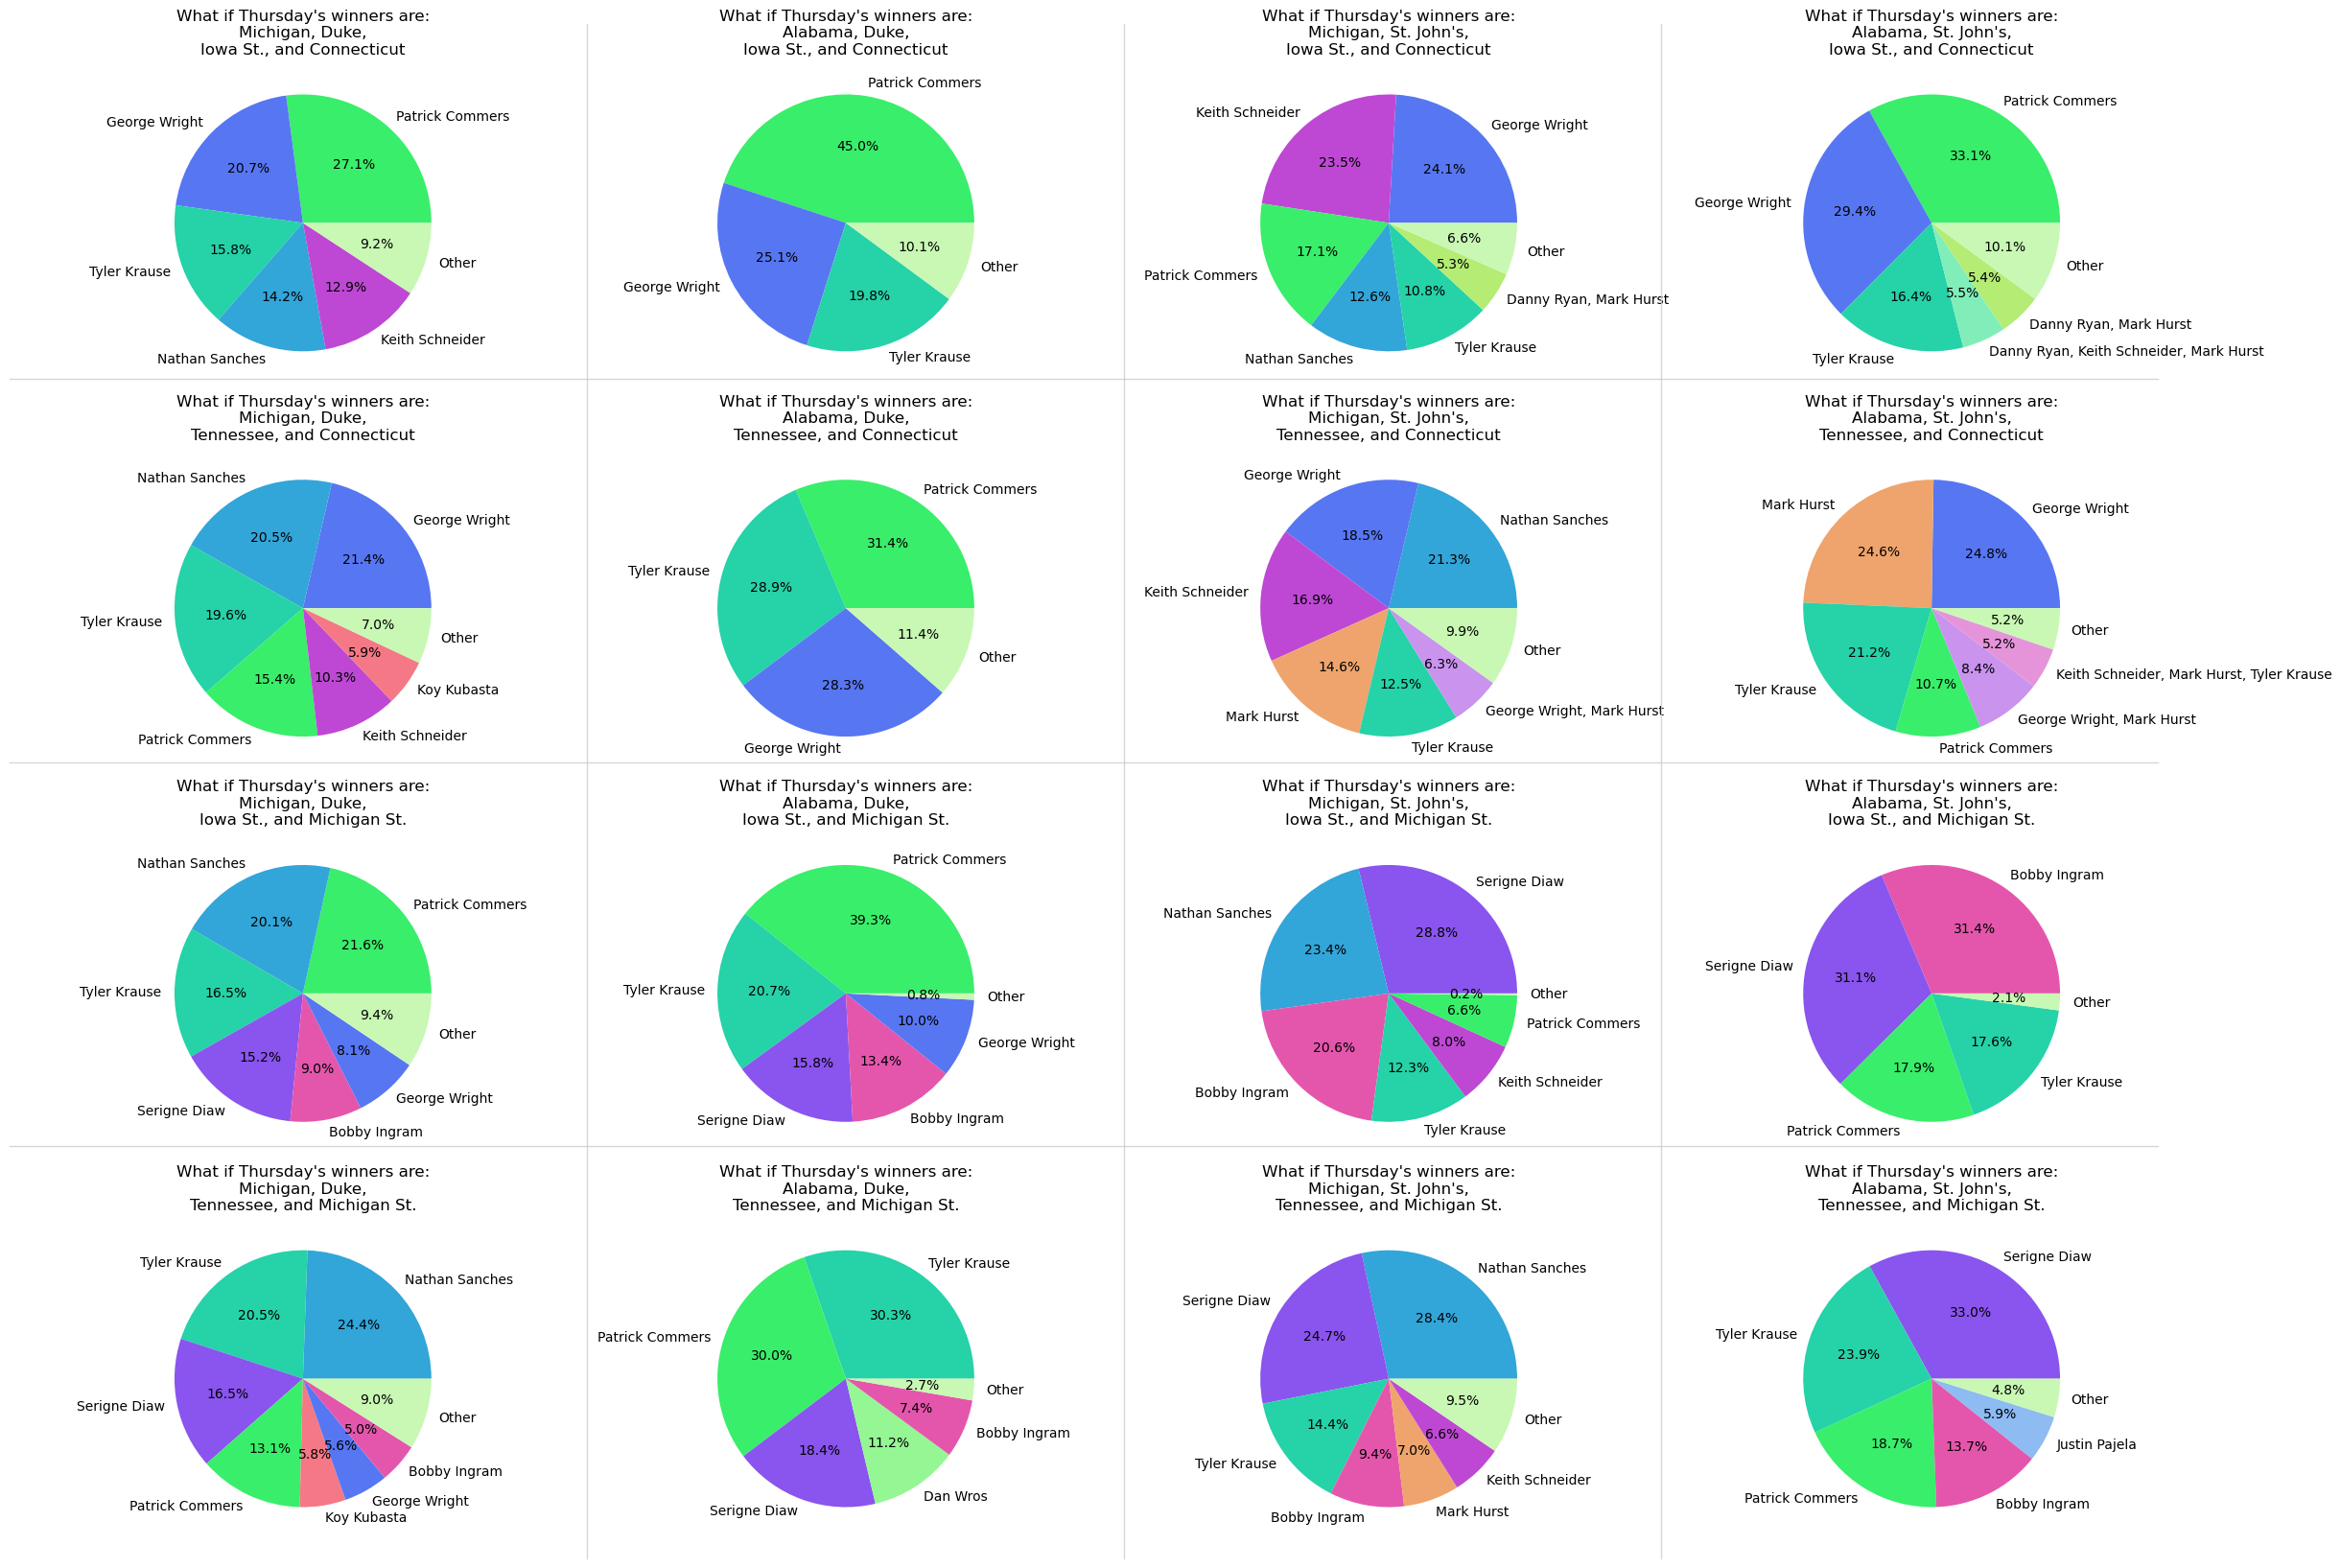

In [36]:
dfs = []
all_labels = []
disp_titles = []

fig, axs = plt.subplots(4, 4, figsize = [28,20])
for ax, vec in zip(axs.flatten(), range(15, -1, -1)):
    results = [(vec>>j) % 2 for j in range(4)]
    winners = [teams[2 * a + b] for a, b in zip(range(4), results)]
    sub_df = tourney_df.loc[(tourney_df[winners[0]] > 2) &
                            (tourney_df[winners[1]] > 2) &
                            (tourney_df[winners[2]] > 2) &
                            (tourney_df[winners[3]] > 2)]
    grouped_df = sub_df[['Winner','Probability']].groupby('Winner').sum().sort_values('Probability', ascending = False)
    grouped_df['Win Probability'] = grouped_df['Probability']/grouped_df['Probability'].sum()
    grouped_df = grouped_df[['Win Probability']]
    grouped_df = grouped_df.loc[grouped_df['Win Probability'] > 0.05]
    other = 1.0 - grouped_df['Win Probability'].sum()
    if other > 0.0001:
        grouped_df.loc['Other'] = [other]
    title = f"""What if Thursday's winners are:
{winners[0]}, {winners[1]},
{winners[2]}, and {winners[3]}"""
    labels = list(grouped_df.index)
    colors = [color_dict[label] for label in labels]
    ax.pie(grouped_df['Win Probability'], 
           labels=grouped_df.index,
           normalize=True,
           autopct='%1.1f%%',
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')



line = plt.Line2D((0.1, 0.9),(0.715, 0.715), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.1, 0.9),(0.515, 0.515), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.1, 0.9),(0.315, 0.315), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.315, 0.315),(0.1, 0.9), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.515, 0.515),(0.1, 0.9), color="#cccc", linewidth=1)
fig.add_artist(line)

line = plt.Line2D((0.715, 0.715),(0.1, 0.9), color="#cccc", linewidth=1)
fig.add_artist(line)

plt.savefig('plots/thursday_what_if.png', dpi=300, bbox_inches='tight')

